<a href="https://colab.research.google.com/github/nmfairuz/ML-Coding/blob/main/K_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Means

K-Means is a Clusterning algo. Here data doesn't have any correct output, we only feed it to the model and model finds patterns and group them together.


How it works:

Initially, the we pick some centroids of some clusters and then it finds the distance from centroi to other points and change the position of the centroid to minize the distance. It keeps repeating the process until the position isn't changing anymore. The nodes closest to the centroid belong to that cluster and after shift of the centroid of the cluster, some nodes go and belong to a different cluster.


Corner Case:

if a centroid isn't close to ny point, best practice is to eliminate it. But if u really need that many centroid, try reassigning the centroids again.

K-Means doesnt use grad descent. It uses L2 norm to find the distance and then change the position of the centroid.

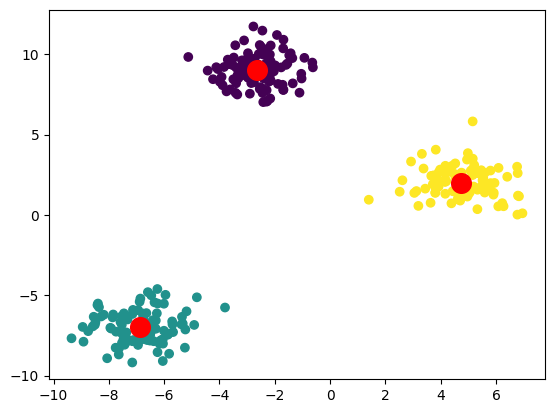

In [2]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# sample data
X, _ = make_blobs(n_samples=300, centers=3, random_state=42)

# model
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

# plot
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, c='red')
plt.show()

n_clusters : You are forcing the number of groups.

Too small → merges different patterns
Too large → splits natural structure

n_init=10 : K-Means depends on random initialization.

So sklearn runs it multiple times and picks the best result

cluster_centers_

This is what you’re really learning:

Each centroid = “average personality” of a group




## Changing number of Clusters:

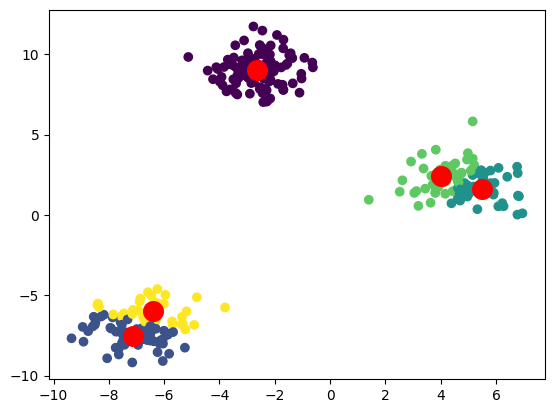

In [5]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# sample data
X, _ = make_blobs(n_samples=300, centers=3, random_state=42)

# model
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X)

# plot
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, c='red')
plt.show()

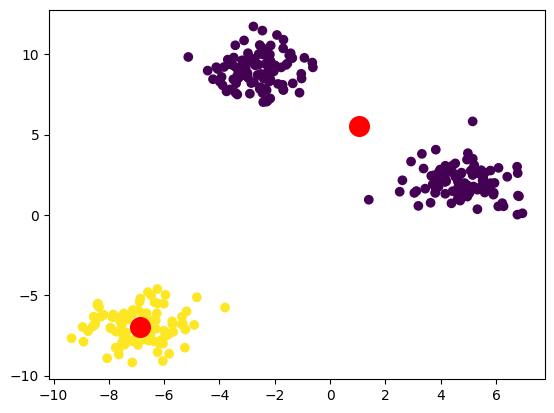

In [6]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# sample data
X, _ = make_blobs(n_samples=300, centers=3, random_state=42)

# model
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X)

# plot
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, c='red')
plt.show()

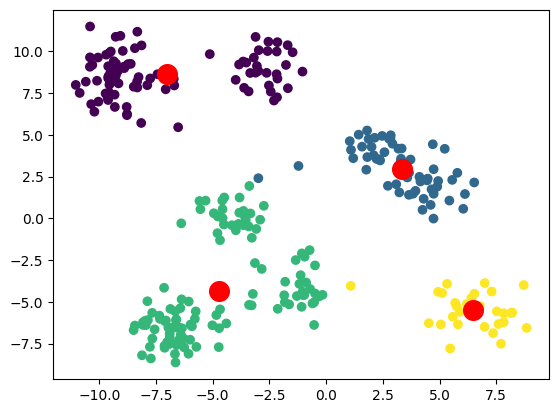

In [7]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# sample data
X, _ = make_blobs(n_samples=300, centers=10, random_state=42)

# model
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X)

# plot
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, c='red')
plt.show()

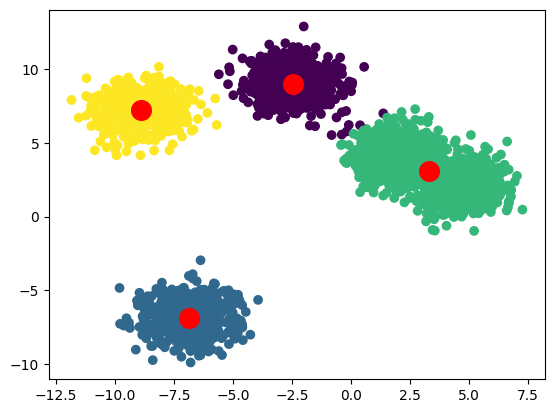

In [10]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# sample data
X, _ = make_blobs(n_samples=3000, centers=5, random_state=42)

# model
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X)

# plot
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, c='red')
plt.show()

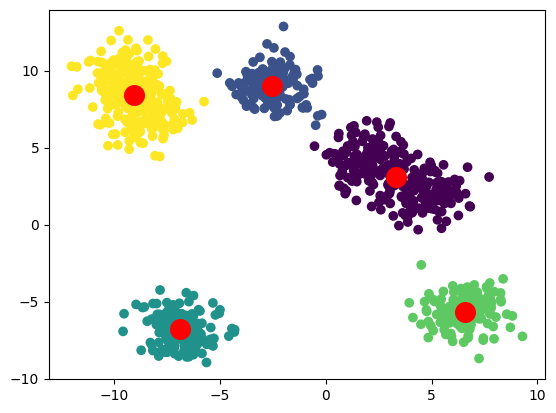

In [11]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# sample data
X, _ = make_blobs(n_samples=1000, centers=7, random_state=42)

# model
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X)

# plot
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, c='red')
plt.show()

## StandardScaler Normalization:

K-Means uses distance (Euclidean distance).

So scale matters a LOT.

Example:

Age: 0–100
Income: 0–100,000

Income will dominate distance → clustering becomes useless.

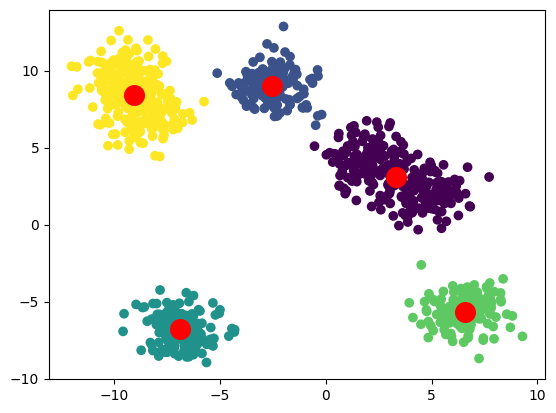

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X)

# plot
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, c='red')
plt.show()


## Elbow Method

This is how you choose K properly.
We measure:

Inertia = how tightly points fit clusters

Low inertia = good clustering
But too many clusters = overfitting

So we find a balance.

### Try Different K

In [15]:
from sklearn.cluster import KMeans

inertias = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)


### plot result

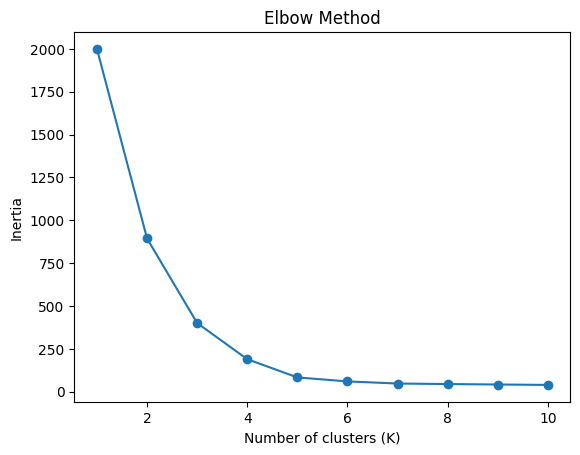

In [16]:
plt.plot(K_range, inertias, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

How to read the graph

You look for a point where:

```inertia stops dropping sharply```

> Inertia = how bad your clustering is (distance error).

It is the sum of squared distances between each point and its assigned centroid

That point = “elbow”

Example shape:

    K=1 → high error
    K=2 → big drop
    K=3 → big drop
    K=4 → smaller drop ← elbow
    K=5 → tiny improvement

Best K ≈ 4

Don’t treat elbow method as “perfect truth”.

It gives a hint
not a guarantee

Sometimes:

no clear elbow exists

real-world clusters are messy

That’s normal.